1. Using A*Search


Yukta Sonawane

========== A* SEARCH (WITHOUT GRAPH) ==========

Current Node : A
['A', 'B']  g = 1  h = 6  f = 7
['A', 'C']  g = 4  h = 5  f = 9
Current Node : B
['A', 'B', 'D']  g = 3  h = 5  f = 8
['A', 'B', 'E']  g = 6  h = 3  f = 9
Current Node : D
['A', 'B', 'D', 'H']  g = 7  h = 2  f = 9
Current Node : C
['A', 'C', 'F']  g = 5  h = 4  f = 9
['A', 'C', 'G']  g = 7  h = 2  f = 9
Current Node : F
['A', 'C', 'F', 'I']  g = 10  h = 1  f = 11
Current Node : E
['A', 'B', 'E', 'H']  g = 8  h = 2  f = 10
Current Node : H
['A', 'B', 'D', 'H', 'Goal']  g = 10  h = 0  f = 10
Current Node : G
['A', 'C', 'G', 'I']  g = 9  h = 1  f = 10
Current Node : I
['A', 'C', 'G', 'I', 'Goal']  g = 11  h = 0  f = 11

Best Path : A -> B -> D -> H -> Goal
Total Cost = 10

========== A* SEARCH WITH GRAPH ==========

Visiting : A
Path : A
g = 0
h = 7
f = 7
--------------------------------
Visiting : B
Path : A -> B
g = 2
h = 6
f = 8
--------------------------------
Visiting : C
Path : A -> C
g = 4
h = 5
f = 9

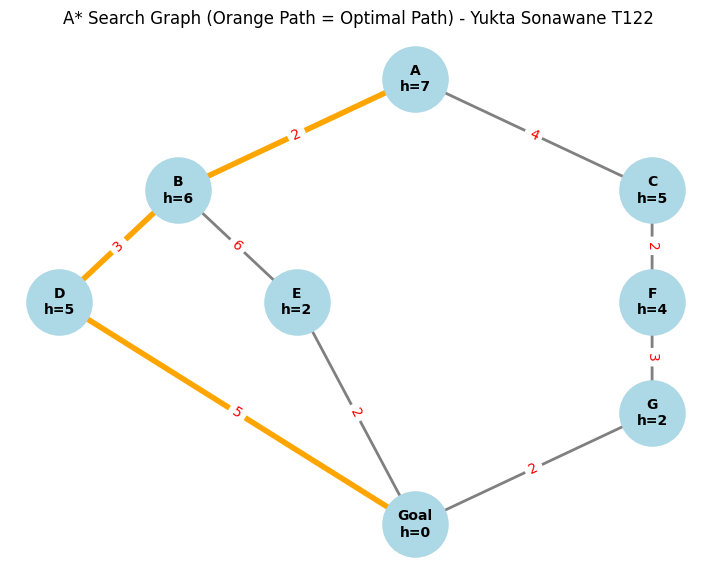

In [10]:
print("Yukta Sonawane")

# ==========================================================
# PROGRAM 1 : A* SEARCH (CONSOLE OUTPUT)
# ==========================================================

from queue import PriorityQueue

graph1 = {
    'A': {'B': 1, 'C': 4},
    'B': {'D': 2, 'E': 5},
    'C': {'F': 1, 'G': 3},
    'D': {'H': 4},
    'E': {'H': 2},
    'F': {'I': 5},
    'G': {'I': 2},
    'H': {'Goal': 3},
    'I': {'Goal': 2},
    'Goal': {}
}

heuristic1 = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 5,
    'E': 3,
    'F': 4,
    'G': 2,
    'H': 2,
    'I': 1,
    'Goal': 0
}

print("\n========== A* SEARCH (WITHOUT GRAPH) ==========\n")

start = 'A'
goal = 'Goal'

pq = PriorityQueue()
pq.put((heuristic1[start], 0, [start]))

visited = set()

while not pq.empty():

    f, g, path = pq.get()
    node = path[-1]

    if node == goal:
        print("\nBest Path :", " -> ".join(path))
        print("Total Cost =", g)
        break

    if node in visited:
        continue

    visited.add(node)

    print("Current Node :", node)

    for neighbour, cost in graph1[node].items():

        new_g = g + cost
        new_f = new_g + heuristic1[neighbour]

        print(path + [neighbour],
              " g =", new_g,
              " h =", heuristic1[neighbour],
              " f =", new_f)

        pq.put((new_f, new_g, path + [neighbour]))

# ==========================================================
# PROGRAM 2 : A* SEARCH WITH GRAPH VISUALIZATION
# ==========================================================

print("\n========== A* SEARCH WITH GRAPH ==========\n")

import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 3, 'E': 6},
    'C': {'F': 2},
    'D': {'Goal': 5},
    'E': {'Goal': 2},
    'F': {'G': 3},
    'G': {'Goal': 2},
    'Goal': {}
}

heuristics = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 5,
    'E': 2,
    'F': 4,
    'G': 2,
    'Goal': 0
}

node_positions = {
    'A': (3, 8),
    'B': (1, 6),
    'C': (5, 6),
    'D': (0, 4),
    'E': (2, 4),
    'F': (5, 4),
    'G': (5, 2),
    'Goal': (3, 0)
}


def a_star_search(graph, heuristics, start, goal):

    priority_queue = [(heuristics[start], start, [start], 0)]

    visited = set()

    while priority_queue:

        f_score, current, path, g_score = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        print("Visiting :", current)
        print("Path :", " -> ".join(path))
        print("g =", g_score)
        print("h =", heuristics[current])
        print("f =", f_score)
        print("--------------------------------")

        if current == goal:
            return path, g_score

        for neighbour, cost in graph[current].items():

            if neighbour not in visited:

                next_g = g_score + cost
                next_f = next_g + heuristics[neighbour]

                heapq.heappush(
                    priority_queue,
                    (next_f, neighbour, path + [neighbour], next_g)
                )

    return None, float("inf")


optimal_path, total_cost = a_star_search(graph, heuristics, 'A', 'Goal')

print("\nOptimal Path :", " -> ".join(optimal_path))
print("Total Cost :", total_cost)

# ==========================================================
# GRAPH VISUALIZATION
# ==========================================================

G = nx.DiGraph()

for node, neighbours in graph.items():
    for neighbour, weight in neighbours.items():
        G.add_edge(node, neighbour, weight=weight)

plt.figure(figsize=(9,7))

path_edges = list(zip(optimal_path, optimal_path[1:]))
normal_edges = [edge for edge in G.edges() if edge not in path_edges]

nx.draw_networkx_nodes(
    G,
    node_positions,
    node_size=2200,
    node_color='lightblue'
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=normal_edges,
    edge_color='gray',
    width=2,
    arrows=True
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=path_edges,
    edge_color='orange',
    width=4,
    arrows=True
)

labels = {}

for node in graph:
    labels[node] = f"{node}\nh={heuristics[node]}"

nx.draw_networkx_labels(
    G,
    node_positions,
    labels,
    font_size=10,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    node_positions,
    edge_labels=edge_labels,
    font_color='red'
)

plt.title("A* Search Graph (Orange Path = Optimal Path) - Yukta Sonawane T122")
plt.axis("off")
plt.show()

 2. MVLU college to Bandra Worli Sea link using A* Search

Yukta Sonawane T122
A* Search: MVLU College to Bandra-Worli Sea Link

========== A* SEARCH ==========

Current Node : MVLU College
Path : MVLU College -> WEH Metro
g(n) = 2
h(n) = 10
f(n) = 12

Path : MVLU College -> Sion
g(n) = 8
h(n) = 9
f(n) = 17

Path : MVLU College -> Santacruz
g(n) = 5
h(n) = 8
f(n) = 13

Current Node : WEH Metro
Path : MVLU College -> WEH Metro -> Bandra Station
g(n) = 10
h(n) = 3
f(n) = 13

Current Node : Santacruz
Path : MVLU College -> Santacruz -> Kalanagar
g(n) = 11
h(n) = 4
f(n) = 15

Current Node : Bandra Station
Path : MVLU College -> WEH Metro -> Bandra Station -> Sea Link
g(n) = 14
h(n) = 0
f(n) = 14


========== RESULT ==========
Best Path :
MVLU College -> WEH Metro -> Bandra Station -> Sea Link
Total Distance : 14 km


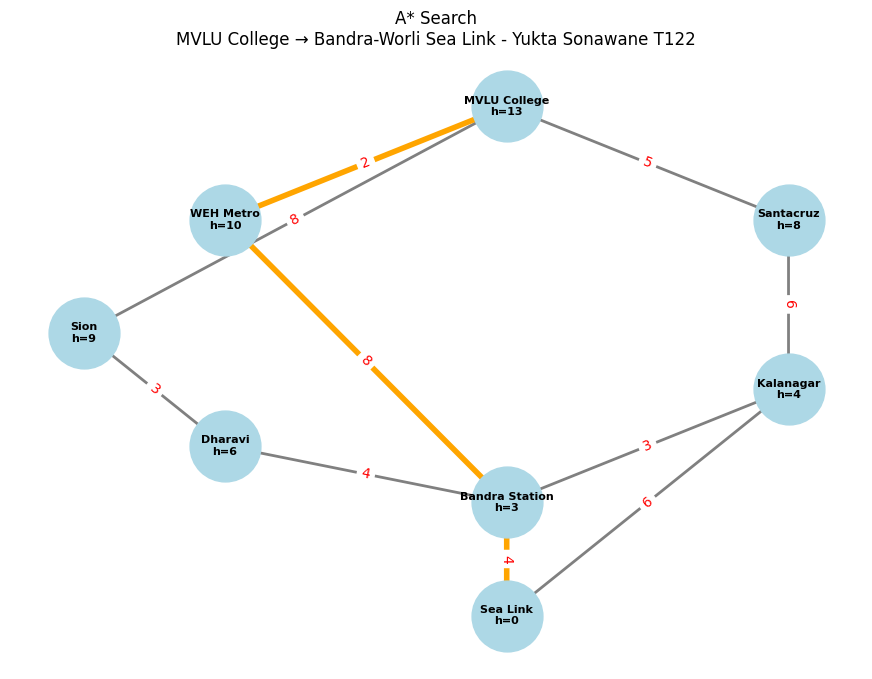

In [12]:
print("Yukta Sonawane T122")
print("A* Search: MVLU College to Bandra-Worli Sea Link")

from queue import PriorityQueue
import matplotlib.pyplot as plt
import networkx as nx

# ----------------------------------------------------
# GRAPH (Approximate Distances in km)
# ----------------------------------------------------

graph = {
    'MVLU College': {
        'WEH Metro': 2,
        'Sion': 8,
        'Santacruz': 5
    },

    'WEH Metro': {
        'Bandra Station': 8
    },

    'Santacruz': {
        'Kalanagar': 6
    },

    'Sion': {
        'Dharavi': 3
    },

    'Dharavi': {
        'Bandra Station': 4
    },

    'Kalanagar': {
        'Bandra Station': 3,
        'Sea Link': 6
    },

    'Bandra Station': {
        'Sea Link': 4
    },

    'Sea Link': {}
}

# ----------------------------------------------------
# Heuristic Values (Estimated Distance to Sea Link)
# ----------------------------------------------------

heuristic = {
    'MVLU College': 13,
    'WEH Metro': 10,
    'Santacruz': 8,
    'Sion': 9,
    'Dharavi': 6,
    'Kalanagar': 4,
    'Bandra Station': 3,
    'Sea Link': 0
}

# ----------------------------------------------------
# A* SEARCH (Console)
# ----------------------------------------------------

start = "MVLU College"
goal = "Sea Link"

print("\n========== A* SEARCH ==========\n")

pq = PriorityQueue()
pq.put((heuristic[start], 0, [start]))

visited = set()

best_path = []
best_cost = 0

while not pq.empty():

    f, g, path = pq.get()

    node = path[-1]

    if node == goal:
        best_path = path
        best_cost = g
        break

    if node in visited:
        continue

    visited.add(node)

    print("Current Node :", node)

    for neighbour, cost in graph[node].items():

        new_g = g + cost
        new_f = new_g + heuristic[neighbour]

        print(f"Path : {' -> '.join(path+[neighbour])}")
        print(f"g(n) = {new_g}")
        print(f"h(n) = {heuristic[neighbour]}")
        print(f"f(n) = {new_f}\n")

        pq.put((new_f, new_g, path+[neighbour]))

print("\n========== RESULT ==========")
print("Best Path :")
print(" -> ".join(best_path))
print("Total Distance :", best_cost, "km")

# ----------------------------------------------------
# GRAPH VISUALIZATION
# ----------------------------------------------------

positions = {
    "MVLU College": (4,8),
    "WEH Metro": (2,6),
    "Santacruz": (6,6),
    "Sion": (1,4),
    "Dharavi": (2,2),
    "Kalanagar": (6,3),
    "Bandra Station": (4,1),
    "Sea Link": (4,-1)
}

G = nx.DiGraph()

for node in graph:
    for neighbour, cost in graph[node].items():
        G.add_edge(node, neighbour, weight=cost)

plt.figure(figsize=(11,8))

path_edges = list(zip(best_path, best_path[1:]))
normal_edges = [e for e in G.edges() if e not in path_edges]

nx.draw_networkx_nodes(
    G,
    positions,
    node_color="lightblue",
    node_size=2600
)

nx.draw_networkx_edges(
    G,
    positions,
    edgelist=normal_edges,
    edge_color="gray",
    width=2,
    arrows=True
)

nx.draw_networkx_edges(
    G,
    positions,
    edgelist=path_edges,
    edge_color="orange",
    width=4,
    arrows=True
)

labels = {}

for node in graph:
    labels[node] = f"{node}\nh={heuristic[node]}"

nx.draw_networkx_labels(
    G,
    positions,
    labels,
    font_size=8,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    positions,
    edge_labels=edge_labels,
    font_color="red"
)

plt.title("A* Search\nMVLU College → Bandra-Worli Sea Link - Yukta Sonawane T122")
plt.axis("off")
plt.show()

3. Recursive Best First Search

Yukta Sonawane T122
Recursive Best-First Search (RBFS)
MVLU College to Bandra-Worli Sea Link

------------------------------------
Current Node : MVLU College
Current Path : MVLU College
g(n) = 0
h(n) = 13
f(n) = 13
------------------------------------
Current Node : WEH Metro
Current Path : MVLU College -> WEH Metro
g(n) = 2
h(n) = 10
f(n) = 12
------------------------------------
Current Node : Bandra Station
Current Path : MVLU College -> WEH Metro -> Bandra Station
g(n) = 10
h(n) = 3
f(n) = 13
------------------------------------
Current Node : Santacruz
Current Path : MVLU College -> Santacruz
g(n) = 5
h(n) = 8
f(n) = 13
------------------------------------
Current Node : WEH Metro
Current Path : MVLU College -> WEH Metro
g(n) = 2
h(n) = 10
f(n) = 12
------------------------------------
Current Node : Bandra Station
Current Path : MVLU College -> WEH Metro -> Bandra Station
g(n) = 10
h(n) = 3
f(n) = 13
------------------------------------
Current Node : Sea Link
Current Path : MVL

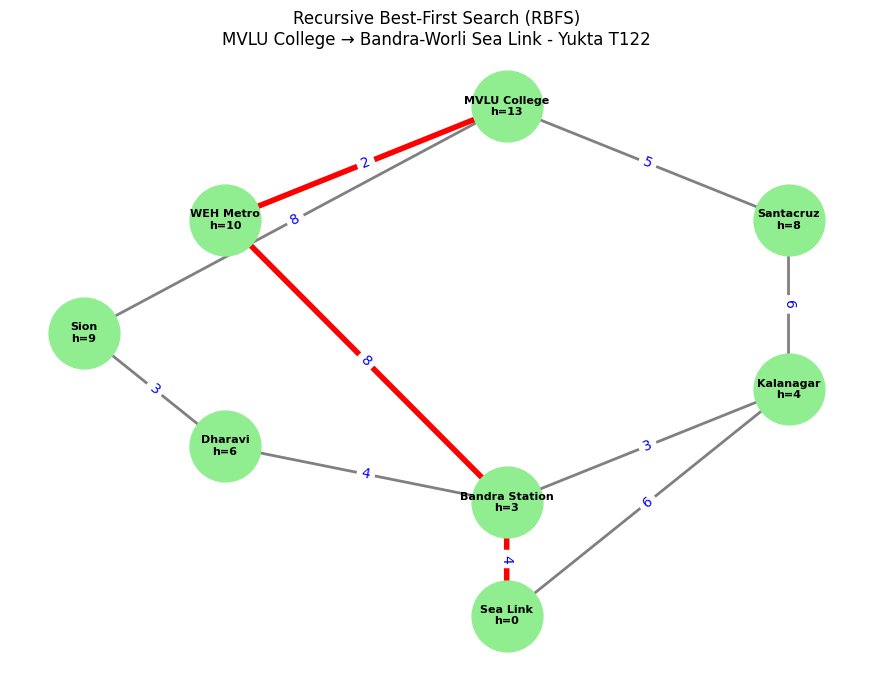

In [13]:
print("Yukta Sonawane T122")
print("Recursive Best-First Search (RBFS)")
print("MVLU College to Bandra-Worli Sea Link\n")

import matplotlib.pyplot as plt
import networkx as nx

# ---------------------------------------------------------
# GRAPH DATA
# ---------------------------------------------------------

graph = {
    'MVLU College': {
        'WEH Metro': 2,
        'Sion': 8,
        'Santacruz': 5
    },

    'WEH Metro': {
        'Bandra Station': 8
    },

    'Santacruz': {
        'Kalanagar': 6
    },

    'Sion': {
        'Dharavi': 3
    },

    'Dharavi': {
        'Bandra Station': 4
    },

    'Kalanagar': {
        'Bandra Station': 3,
        'Sea Link': 6
    },

    'Bandra Station': {
        'Sea Link': 4
    },

    'Sea Link': {}
}

# ---------------------------------------------------------
# Heuristic Values
# ---------------------------------------------------------

heuristic = {
    'MVLU College': 13,
    'WEH Metro': 10,
    'Santacruz': 8,
    'Sion': 9,
    'Dharavi': 6,
    'Kalanagar': 4,
    'Bandra Station': 3,
    'Sea Link': 0
}

goal = "Sea Link"

# ---------------------------------------------------------
# RECURSIVE BEST-FIRST SEARCH
# ---------------------------------------------------------

def rbfs(node, path, g, f_limit):

    print("------------------------------------")
    print("Current Node :", node)
    print("Current Path :", " -> ".join(path))
    print("g(n) =", g)
    print("h(n) =", heuristic[node])
    print("f(n) =", g + heuristic[node])

    if node == goal:
        return path, g

    successors = []

    for child, cost in graph[node].items():

        new_g = g + cost

        new_f = max(
            new_g + heuristic[child],
            g + heuristic[node]
        )

        successors.append([child, new_g, new_f])

    if len(successors) == 0:
        return None, float("inf")

    while True:

        successors.sort(key=lambda x: x[2])

        best = successors[0]

        if best[2] > f_limit:
            return None, best[2]

        if len(successors) > 1:
            alternative = successors[1][2]
        else:
            alternative = float("inf")

        result, best[2] = rbfs(
            best[0],
            path + [best[0]],
            best[1],
            min(f_limit, alternative)
        )

        if result is not None:
            return result, best[2]

# ---------------------------------------------------------
# RUN RBFS
# ---------------------------------------------------------

best_path, total_cost = rbfs(
    "MVLU College",
    ["MVLU College"],
    0,
    float("inf")
)

print("\n========== RESULT ==========")
print("Best Path :")
print(" -> ".join(best_path))
print("Total Distance :", total_cost, "km")

# ---------------------------------------------------------
# GRAPH VISUALIZATION
# ---------------------------------------------------------

positions = {
    "MVLU College": (4,8),
    "WEH Metro": (2,6),
    "Santacruz": (6,6),
    "Sion": (1,4),
    "Dharavi": (2,2),
    "Kalanagar": (6,3),
    "Bandra Station": (4,1),
    "Sea Link": (4,-1)
}

G = nx.DiGraph()

for node in graph:
    for neighbour, cost in graph[node].items():
        G.add_edge(node, neighbour, weight=cost)

plt.figure(figsize=(11,8))

path_edges = list(zip(best_path, best_path[1:]))
other_edges = [e for e in G.edges() if e not in path_edges]

nx.draw_networkx_nodes(
    G,
    positions,
    node_size=2600,
    node_color="lightgreen"
)

nx.draw_networkx_edges(
    G,
    positions,
    edgelist=other_edges,
    edge_color="gray",
    width=2,
    arrows=True
)

nx.draw_networkx_edges(
    G,
    positions,
    edgelist=path_edges,
    edge_color="red",
    width=4,
    arrows=True
)

labels = {}

for node in graph:
    labels[node] = f"{node}\nh={heuristic[node]}"

nx.draw_networkx_labels(
    G,
    positions,
    labels,
    font_size=8,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    positions,
    edge_labels=edge_labels,
    font_color="blue"
)

plt.title("Recursive Best-First Search (RBFS)\nMVLU College → Bandra-Worli Sea Link - Yukta T122")
plt.axis("off")
plt.show()

Comparison